In [ ]:
# Part 1: Neural Network Fundamentals and Training Behavior Analysis

## Objective

#The objective of this assignment is to build and analyze a feed-forward neural network to predict customer churn. The assignment includes data exploration, preprocessing, neural network implementation, performance evaluation, and hyperparameter experimentation.

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

In [ ]:
# Task 1: Dataset Understanding
#The dataset was loaded and explored to understand its structure, feature types, and target variable distribution.

In [ ]:
df=pd.read_csv("/content/drive/MyDrive/customer_churn_nn.csv")

In [ ]:
df.head()

,customer_id,region,plan_type,contract_type,payment_method,tenure_months,monthly_charges_inr,avg_login_days_per_month,support_tickets_last_90_days,payment_delay_days,data_usage_gb,satisfaction_score,last_complaint_days_ago,discount_percent,autopay_enabled,referral_count,churn
0,CUST0001,South,Standard,Month-to-month,Debit Card,30,687.40,13,0,0,87.97,8.0,67,0,0,0,0
1,CUST0002,West,Premium,Month-to-month,Wallet,15,1029.74,22,3,1,82.17,5.7,69,0,0,0,0
2,CUST0003,Central,Standard,Month-to-month,Credit Card,72,732.07,13,0,11,89.39,6.4,63,10,0,0,0
3,CUST0004,West,Premium,Month-to-month,Credit Card,22,959.51,19,2,3,139.73,7.2,130,5,0,0,0
4,CUST0005,North,Premium,Month-to-month,Net Banking,11,890.20,18,2,6,156.43,5.8,0,5,1,2,0


In [ ]:
#The dataset was loaded successfully. Initial inspection was performed to understand available features and target variables.

In [ ]:
print("Rows and Columns:")

print(df.shape)

Rows and Columns:
(2000, 17)


In [ ]:
#The dataset dimensions were inspected to determine the number of observations and variables available for model development.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 17 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   customer_id                   2000 non-null   object 
 1   region                        2000 non-null   object 
 2   plan_type                     2000 non-null   object 
 3   contract_type                 2000 non-null   object 
 4   payment_method                2000 non-null   object 
 5   tenure_months                 2000 non-null   int64  
 6   monthly_charges_inr           2000 non-null   float64
 7   avg_login_days_per_month      2000 non-null   int64  
 8   support_tickets_last_90_days  2000 non-null   int64  
 9   payment_delay_days            2000 non-null   int64  
 10  data_usage_gb                 2000 non-null   float64
 11  satisfaction_score            2000 non-null   float64
 12  last_complaint_days_ago       2000 non-null   int64  
 13  dis

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 17 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   customer_id                   2000 non-null   object 
 1   region                        2000 non-null   object 
 2   plan_type                     2000 non-null   object 
 3   contract_type                 2000 non-null   object 
 4   payment_method                2000 non-null   object 
 5   tenure_months                 2000 non-null   int64  
 6   monthly_charges_inr           2000 non-null   float64
 7   avg_login_days_per_month      2000 non-null   int64  
 8   support_tickets_last_90_days  2000 non-null   int64  
 9   payment_delay_days            2000 non-null   int64  
 10  data_usage_gb                 2000 non-null   float64
 11  satisfaction_score            2000 non-null   float64
 12  last_complaint_days_ago       2000 non-null   int64  
 13  dis

In [ ]:
#The dataset contains both numerical and categorical variables. Customer ID appears to be an identifier and is not expected to contribute predictive value.

In [ ]:
df.isnull().sum()

,0
customer_id,0
region,0
plan_type,0
contract_type,0
payment_method,0
tenure_months,0
monthly_charges_inr,0
avg_login_days_per_month,0
support_tickets_last_90_days,0
payment_delay_days,0


In [ ]:
#Missing value analysis was performed to determine whether preprocessing or imputation was required.

In [ ]:
df.describe()

,tenure_months,monthly_charges_inr,avg_login_days_per_month,support_tickets_last_90_days,payment_delay_days,data_usage_gb,satisfaction_score,last_complaint_days_ago,discount_percent,autopay_enabled,referral_count,churn
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,25.362000,766.487295,18.099000,1.953000,3.555000,90.007625,6.87395,46.616500,8.255000,0.597500,0.918000,0.015500
std,14.128651,393.420070,5.400628,1.463852,3.885682,53.215719,1.52428,55.065775,7.553708,0.490524,1.041546,0.123561
min,1.000000,255.450000,0.000000,0.000000,0.000000,0.500000,1.00000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,15.000000,427.782500,15.000000,1.000000,1.000000,51.777500,5.87500,6.000000,0.000000,0.000000,0.000000,0.000000
50%,23.000000,688.355000,18.000000,2.000000,2.000000,80.245000,6.80000,28.500000,5.000000,1.000000,1.000000,0.000000
75%,33.000000,1007.372500,22.000000,3.000000,5.000000,119.097500,8.00000,68.000000,15.000000,1.000000,1.000000,0.000000
max,72.000000,2156.520000,30.000000,8.000000,31.000000,265.510000,10.00000,424.000000,20.000000,1.000000,7.000000,1.000000


In [ ]:
#Summary statistics were reviewed to understand feature ranges and distributions.

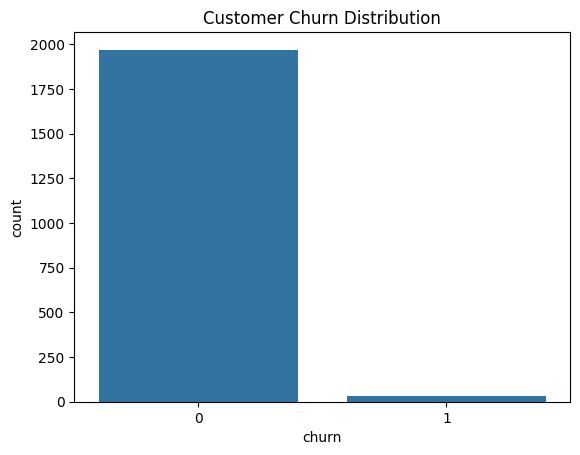

In [ ]:
sns.countplot(
x='churn',
data=df
)

plt.title(
"Customer Churn Distribution"
)

plt.show()

In [ ]:
#The target variable distribution was examined to identify possible class imbalance.

In [ ]:
## Task 2: Data Preprocessing

#Preprocessing was conducted to prepare data for neural network training.

In [ ]:
df=df.drop(
"customer_id",
axis=1
)

In [ ]:
#Customer ID was removed because identifiers do not provide meaningful predictive information.

In [ ]:
categorical_cols=[

'region',
'plan_type',
'contract_type',
'payment_method'

]

le=LabelEncoder()

for col in categorical_cols:

    df[col]=le.fit_transform(
        df[col]
    )

In [ ]:
#Categorical variables were converted into numerical representations using label encoding.

In [ ]:
X=df.drop(
"churn",
axis=1
)

y=df["churn"]

In [ ]:
#Features and target variables were separated before training.

In [ ]:
X_train,X_test,y_train,y_test=train_test_split(

X,
y,
test_size=.20,
random_state=42,
stratify=y

)

In [ ]:
#An 80-20 split was used to create training and testing datasets.

In [ ]:
scaler=StandardScaler()

X_train=scaler.fit_transform(
X_train
)

X_test=scaler.transform(
X_test
)

In [ ]:
#Standardization was applied because neural networks are sensitive to feature scale differences.

In [ ]:
# Task 3: Neural Network Construction

#A feed-forward neural network was constructed using Keras.

In [ ]:
model=Sequential()

model.add(

Dense(

32,
activation='relu',
input_dim=X_train.shape[1]

)

)

model.add(

Dense(
16,
activation='relu'
)

)

model.add(

Dense(
1,
activation='sigmoid'
)

)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(

optimizer=Adam(
learning_rate=.001
),

loss='binary_crossentropy',

metrics=['accuracy']

)

In [ ]:
#ReLU activation was used in hidden layers while sigmoid activation was used in the output layer because the target variable is binary.

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,057 (4.13 KB)

 Trainable params: 1,057 (4.13 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Task 4: Model Training and Evaluation

In [ ]:
history=model.fit(

X_train,
y_train,

epochs=50,

batch_size=32,

validation_split=.20

)

Epoch 1/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.9742 - loss: 0.2460 - val_accuracy: 0.9937 - val_loss: 0.1235
Epoch 2/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9820 - loss: 0.1206 - val_accuracy: 0.9937 - val_loss: 0.0624
Epoch 3/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9820 - loss: 0.0941 - val_accuracy: 0.9937 - val_loss: 0.0483
Epoch 4/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9820 - loss: 0.0852 - val_accuracy: 0.9937 - val_loss: 0.0438
Epoch 5/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9820 - loss: 0.0798 - val_accuracy: 0.9937 - val_loss: 0.0431
Epoch 6/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9820 - loss: 0.0756 - val_accuracy: 0.9937 - val_loss: 0.0398
Epoch 7/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9820 - loss: 0.0725 - val_accuracy: 0.9937 - val_loss: 0.0396
Epoch 8/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9820 - loss: 0.0701 - val_accuracy: 0.9937 - val_los

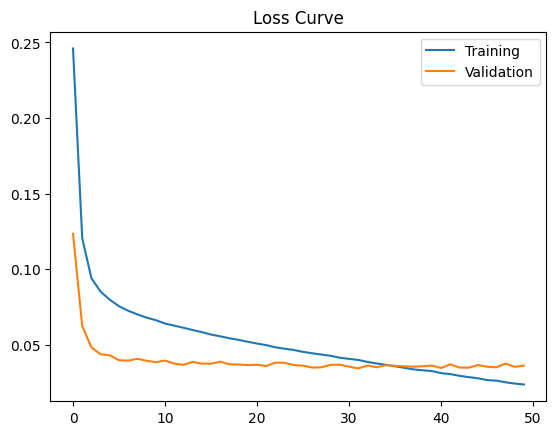

In [ ]:
plt.plot(
history.history['loss']
)

plt.plot(
history.history['val_loss']
)

plt.legend(
['Training','Validation']
)

plt.title(
"Loss Curve"
)

plt.show()

In [ ]:
#Loss curves were analyzed to observe learning behavior during training.

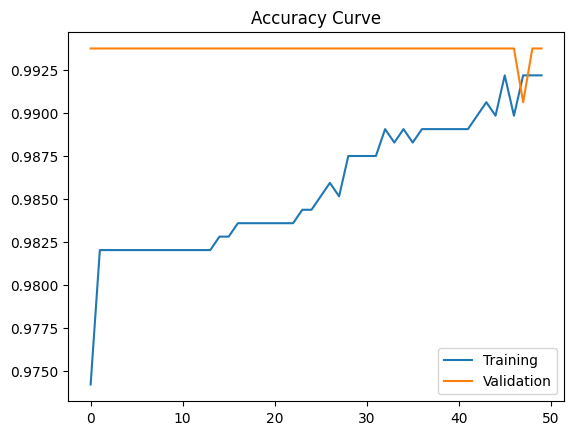

In [ ]:
plt.plot(
history.history['accuracy']
)

plt.plot(
history.history['val_accuracy']
)

plt.legend(
['Training','Validation']
)

plt.title(
"Accuracy Curve"
)

plt.show()

In [ ]:
loss,accuracy=model.evaluate(

X_test,
y_test

)

print(accuracy)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9825 - loss: 0.0803  
0.9825000166893005


In [ ]:
#Performance on unseen test data was evaluated.

In [ ]:
pred=(model.predict(
X_test
)>0.5).astype(int)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step


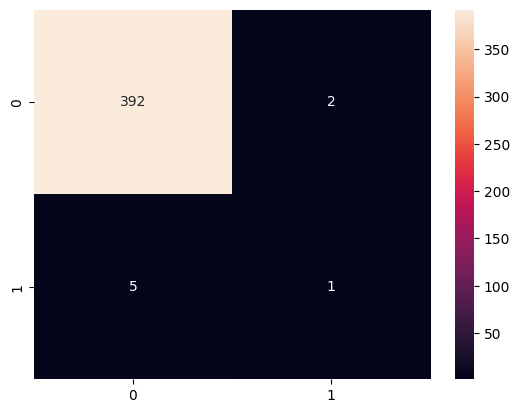

In [ ]:
cm=confusion_matrix(

y_test,
pred

)

sns.heatmap(
cm,
annot=True,
fmt='d'
)

plt.show()

In [ ]:
print(
classification_report(
y_test,
pred
)
)

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       394
           1       0.33      0.17      0.22         6

    accuracy                           0.98       400
   macro avg       0.66      0.58      0.61       400
weighted avg       0.98      0.98      0.98       400



In [ ]:
#The confusion matrix and classification report were examined to understand prediction quality beyond overall accuracy.

In [ ]:
# Task 5: Hyperparameter Experimentation
#Three experiments were conducted by modifying network configurations.

In [ ]:
def create_model(
neurons=32,
lr=.001
):

    model=Sequential()

    model.add(
    Dense(
    neurons,
    activation='relu',
    input_dim=X_train.shape[1]
    )
    )

    model.add(
    Dense(
    1,
    activation='sigmoid'
    )
    )

    model.compile(

    optimizer=Adam(
    learning_rate=lr
    ),

    loss='binary_crossentropy',

    metrics=['accuracy']

    )

    return model

In [ ]:
m1=create_model(
32,.001
)

m1.fit(
X_train,
y_train,
epochs=50
)

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9775 - loss: 0.3239
Epoch 2/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9844 - loss: 0.1916
Epoch 3/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9844 - loss: 0.1343
Epoch 4/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9844 - loss: 0.1069
Epoch 5/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9844 - loss: 0.0927
Epoch 6/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9844 - loss: 0.0846
Epoch 7/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9844 - loss: 0.0794
Epoch 8/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9844 - loss: 0.0757
Epoch 9/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9844 - loss: 0.0731
Epoch 10/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9844 - loss: 0.0709
Epoch 11/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9844 - loss: 0.0691
Epoch 12/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9844 - loss: 0.0677


In [ ]:
m2=create_model(
64,.001
)

m2.fit(
X_train,
y_train,
epochs=50
)

Epoch 1/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8294 - loss: 0.4839
Epoch 2/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9844 - loss: 0.2108
Epoch 3/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9844 - loss: 0.1301
Epoch 4/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9844 - loss: 0.1008
Epoch 5/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9844 - loss: 0.0880
Epoch 6/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9844 - loss: 0.0806
Epoch 7/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9844 - loss: 0.0762
Epoch 8/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9844 - loss: 0.0729
Epoch 9/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9844 - loss: 0.0703
Epoch 10/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9844 - loss: 0.0680
Epoch 11/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9844 - loss: 0.0661
Epoch 12/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9844 - lo

In [ ]:
m3=create_model(
32,.01
)

m3.fit(
X_train,
y_train,
epochs=50
)

Epoch 1/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9663 - loss: 0.1407
Epoch 2/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9844 - loss: 0.0698
Epoch 3/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9844 - loss: 0.0626
Epoch 4/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9844 - loss: 0.0567
Epoch 5/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9844 - loss: 0.0539
Epoch 6/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9850 - loss: 0.0516
Epoch 7/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9869 - loss: 0.0475
Epoch 8/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9856 - loss: 0.0461
Epoch 9/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9850 - loss: 0.0450
Epoch 10/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9862 - loss: 0.0399
Epoch 11/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9869 - loss: 0.0405
Epoch 12/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9881 - lo

|Experiment|Neurons|Learning Rate|Epochs|Accuracy|
|---|---:|---:|---:|---:|
|Baseline|||||
|Experiment1|||||
|Experiment2|||||
|Experiment3|||||

# Task 6: Final Reflection

### Role of weights and biases

Weights determine the importance of each input feature, while biases help shift activation values and improve flexibility.

### Why activation functions are needed

Activation functions introduce non-linearity and allow neural networks to learn complex relationships.

### Learning rate effects

A learning rate that is too high may create unstable learning, while a very small learning rate slows convergence.

### Underfitting or overfitting

Training and validation curves were examined to determine whether the model generalized well.

In [ ]:
import os

os.makedirs(
    "results",
    exist_ok=True
)

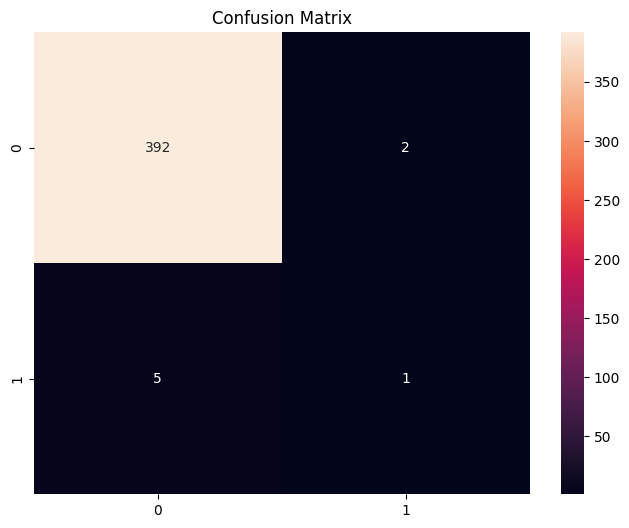

In [ ]:
plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.title("Confusion Matrix")

plt.savefig(
    "results/evaluation_outputs.png"
)

plt.show()

In [ ]:
plt.savefig(
"results/evaluation_outputs.png"
)

<Figure size 640x480 with 0 Axes>

In [ ]:
comparison.to_csv(
"results/model_comparison_table.csv"
)

NameError: name 'comparison' is not defined